In [1]:
import pandas as pd

df = pd.read_csv("materials_featurized.csv")

X = df.drop(columns=["band_gap"])
y = df["band_gap"]

X.columns[0:3]

Index(['MagpieData minimum Number', 'MagpieData maximum Number',
       'MagpieData range Number'],
      dtype='object')

In [ ]:
# DATA SPLITTING

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [ ]:
# RANDOM FOREST AND CALCULATING THE MAE VALUES

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf_model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state= 42)

rf_model.fit(X_train, y_train)

y_train_prediction = rf_model.predict(X_train)
y_val_prediction = rf_model.predict(X_val)
y_test_prediction_rf = rf_model.predict(X_test)

mae_train = mean_absolute_error(y_train, y_train_prediction)
mae_val = mean_absolute_error(y_val, y_val_prediction)
mae_test = mean_absolute_error(y_test, y_test_prediction_rf)

print("Training MAE: ", mae_train, "eV")
print("Validation MAE: ", mae_val, "eV")
print("Test MAE (RF): ", mae_test, "eV")

Training MAE:  0.1194931002553507 eV
Validation MAE:  0.303677434108158 eV
Test MAE (RF):  0.3197171384773367 eV


In [ ]:
# SCALING THE SPLITTED DATASETS FOR NEURAL NETWORK

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# X_train_scaled.shape
X_train_scaled[:,0].std()

np.float64(1.0)

In [ ]:
# TURNING SCALED SETS INTO TENSORS

import torch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1,1)

y_val_tensor.shape

torch.Size([5096, 1])

In [ ]:
# ESTABLISHING THE NEURAL NETWORK

import torch.nn as nn

class deeperBandgapNN(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_size2, output_size)
    
    def forward(self, x):
        out = self.relu1(self.fc1(x))
        out = self.relu2(self.fc2(out))
        out = self.fc3(out)

        return out

In [ ]:
# ADDING LOSS FUNCTION AND OPTIMIZER 

NN_model = deeperBandgapNN(input_size=132, hidden_size1=256, hidden_size2=128, output_size=1)

import torch.optim as optim

loss_function = nn.MSELoss()

optimizer = optim.Adam(NN_model.parameters(), lr=0.001)


In [ ]:
# TRAINING THE TRAINIGN AND VALIDATION SETS WITH NEURAL NETWORK MODEL, CALCULATING BOTH LOSSES 

num_epochs = 800

best_val_loss = float('inf')

for epoch in range(num_epochs):
    NN_model.train()
    optimizer.zero_grad()

    y_train_predicted = NN_model(X_train_tensor)
    train_loss = loss_function(y_train_predicted, y_train_tensor)
    train_loss.backward()

    optimizer.step()

    NN_model.eval()
    with torch.no_grad():
        y_val_predicted = NN_model(X_val_tensor)
        val_loss = loss_function(y_val_predicted, y_val_tensor)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(NN_model.state_dict(), 'best_nn_model.pth')
        print(f"-> Best model saved at epoch {epoch+1} is Val Loss : {val_loss.item():.4f}")
    
    if (epoch+1)%80 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss : {train_loss.item():.4f}, Val Loss : {val_loss.item():.4f}")


-> Best model saved at epoch 1 is Val Loss : 3.7385
-> Best model saved at epoch 2 is Val Loss : 3.2211
-> Best model saved at epoch 3 is Val Loss : 2.7324
-> Best model saved at epoch 4 is Val Loss : 2.2679
-> Best model saved at epoch 5 is Val Loss : 1.8439
-> Best model saved at epoch 6 is Val Loss : 1.5005
-> Best model saved at epoch 7 is Val Loss : 1.2963
-> Best model saved at epoch 8 is Val Loss : 1.2699
-> Best model saved at epoch 13 is Val Loss : 1.1819
-> Best model saved at epoch 14 is Val Loss : 1.0951
-> Best model saved at epoch 15 is Val Loss : 1.0560
-> Best model saved at epoch 23 is Val Loss : 1.0163
-> Best model saved at epoch 24 is Val Loss : 0.9753
-> Best model saved at epoch 25 is Val Loss : 0.9449
-> Best model saved at epoch 26 is Val Loss : 0.9281
-> Best model saved at epoch 27 is Val Loss : 0.9230
-> Best model saved at epoch 30 is Val Loss : 0.9173
-> Best model saved at epoch 31 is Val Loss : 0.9059
-> Best model saved at epoch 32 is Val Loss : 0.8929
-

In [15]:
import numpy as np

NN_model.eval()
with torch.no_grad():
    y_train_pred_outloop = NN_model(X_train_tensor)
    y_train_pred_numpy = y_train_pred_outloop.numpy().flatten()
    y_train_true_numpy = y_train_tensor.numpy().flatten()

    y_val_pred_outloop = NN_model(X_val_tensor)
    y_val_pred_numpy = y_val_pred_outloop.numpy().flatten()
    y_val_true_numpy = y_val_tensor.numpy().flatten()

mae_train_updated = mean_absolute_error(y_train_true_numpy, y_train_pred_numpy)
mae_val_updated = mean_absolute_error(y_val_true_numpy, y_val_pred_numpy)

NN_model.load_state_dict(torch.load('best_nn_model.pth'))
print(f"Loaded best model with validation loss {best_val_loss:.4f}")

print(mae_train_updated, mae_val_updated)

    

Loaded best model with validation loss 0.4223
0.277482807636261 0.3796131908893585


In [16]:
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [17]:
NN_model.eval()
with torch.no_grad():
    y_test_predicted_numpy = NN_model(X_test_tensor).numpy().flatten()
    y_test_true_numpy = y_test_tensor.numpy().flatten()

mae_test = mean_absolute_error(y_test_true_numpy, y_test_predicted_numpy)

print(f"Neural Network Test MAE: {mae_test:.3f} eV")

Neural Network Test MAE: 0.378 eV


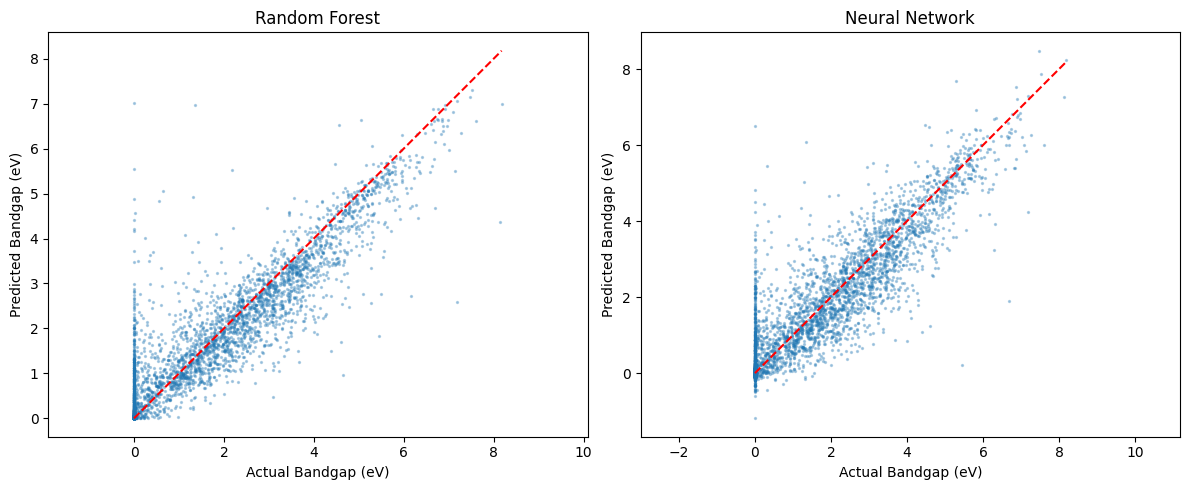

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].scatter(y_test, y_test_prediction_rf, alpha=0.3, s=2)
ax[0].plot([0, max(y_test)],[0, max(y_test)], 'r--')
ax[0].set_xlabel("Actual Bandgap (eV)")
ax[0].set_ylabel("Predicted Bandgap (eV)")
ax[0].set_title("Random Forest")
ax[0].axis('equal')

ax[1].scatter(y_test_true_numpy, y_test_predicted_numpy, alpha=0.3, s=2)
ax[1].plot([0, max(y_test_true_numpy)], [0, max(y_test_true_numpy)], 'r--')
ax[1].set_xlabel("Actual Bandgap (eV)")
ax[1].set_ylabel("Predicted Bandgap (eV)")
ax[1].set_title("Neural Network")
ax[1].axis('equal')

plt.tight_layout()
plt.show()

In [19]:
import pandas as pd

df_eda = pd.read_csv("materials_data_eda.csv")

test_idx = X_test.index

test_band_types = df_eda.loc[test_idx,'band_type']

metal_mask = (test_band_types == "metal")

# metal_mask.sum()

y_test_metal = y_test[metal_mask]

y_predicted_rf_metal = y_test_prediction_rf[metal_mask]
y_predicted_numpy_metal = y_test_predicted_numpy[metal_mask]

mae_rf_metal = mean_absolute_error(y_test_metal, y_predicted_rf_metal)
mae_numpy_metal = mean_absolute_error(y_test_metal, y_predicted_numpy_metal)
print("Metal :", mae_rf_metal, mae_numpy_metal)

non_metal_mask = (test_band_types != "metal")
# non_metal_mask.sum()

y_test_non_metal = y_test[non_metal_mask]

y_predicted_rf_non_metal = y_test_prediction_rf[non_metal_mask]
y_predicted_numpy_non_metal = y_test_predicted_numpy[non_metal_mask]

mae_rf_non_metal = mean_absolute_error(y_test_non_metal, y_predicted_rf_non_metal)
mae_numpy_non_metal = mean_absolute_error(y_test_non_metal, y_predicted_numpy_non_metal)
print("Non-metal :", mae_rf_non_metal, mae_numpy_non_metal)

Metal : 0.13063638654482845 0.15733082785442146
Non-metal : 0.5042523275483421 0.5929289139039251


In [28]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

top20 = importance_df.head(20)
print(top20)

                                  feature  importance
23               MagpieData mode MeltingT    0.423744
63              MagpieData mean NdValence    0.091346
7      MagpieData maximum MendeleevNumber    0.041639
21               MagpieData mean MeltingT    0.035146
64           MagpieData avg_dev NdValence    0.025080
33                    MagpieData mean Row    0.017028
28              MagpieData avg_dev Column    0.012489
45      MagpieData mean Electronegativity    0.012475
46   MagpieData avg_dev Electronegativity    0.012200
57              MagpieData mean NpValence    0.012055
74              MagpieData range NValence    0.010614
98            MagpieData range NfUnfilled    0.010531
104            MagpieData range NUnfilled    0.009436
97          MagpieData maximum NfUnfilled    0.009282
105             MagpieData mean NUnfilled    0.009113
20              MagpieData range MeltingT    0.009106
129      MagpieData mean SpaceGroupNumber    0.008938
106          MagpieData avg_

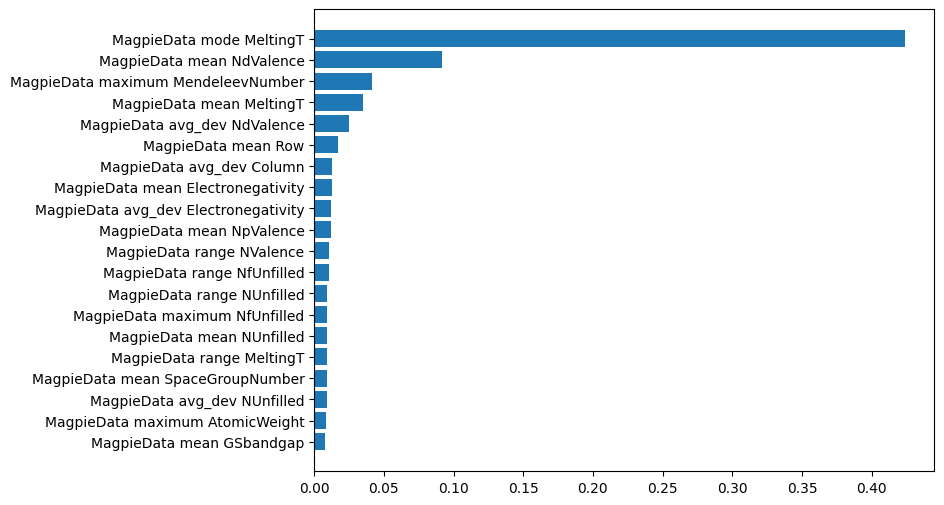

In [33]:
fig, ax = plt.subplots(figsize=(8,6))
ax = plt.barh(top20['feature'][::-1], top20['importance'][::-1])

In [34]:
mae_train

0.1194931002553507